In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from collections import defaultdict

In [2]:
hdul = fits.open('25192.fits')
#'cat_21_3.fits')
catalog = hdul[1].data
data_header = hdul[1].header
table_hdu = hdul[1]
cols = table_hdu.columns
hdul.close()


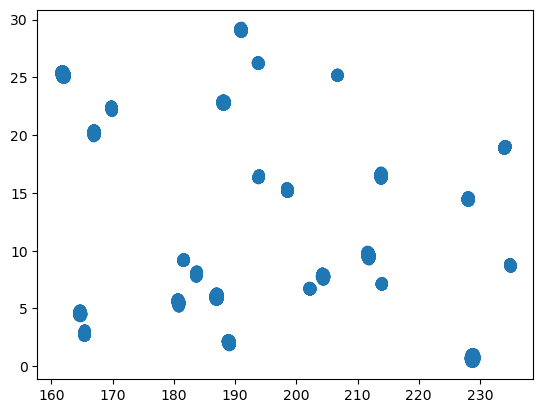

In [3]:
plt.scatter(catalog['ra_gal'], catalog['dec_gal'])

In [4]:
np.unique(catalog['halo_id'])

array([3540350196678, 3542370665932, 3544360043075, 3545380349863,
       3739350897596, 3740360074867, 3740360529492, 3838370682076,
       3840360729382, 3845360361913, 3938350271698, 3939350664369,
       3939380821520, 3943390113633, 4036350332263, 4036370818677,
       4037350546841, 4037370014509, 4039350321288, 4041370090393,
       4044360321731, 4240360271546, 4240360760992, 4242400187314,
       4338380622430], dtype='>i8')

In [5]:
unique_halo_ids = np.unique(catalog['halo_id'])
subcatalogs = {hid: catalog[catalog['halo_id'] == hid] for hid in unique_halo_ids}
subcatalog_list = [catalog[catalog['halo_id'] == hid] for hid in unique_halo_ids]

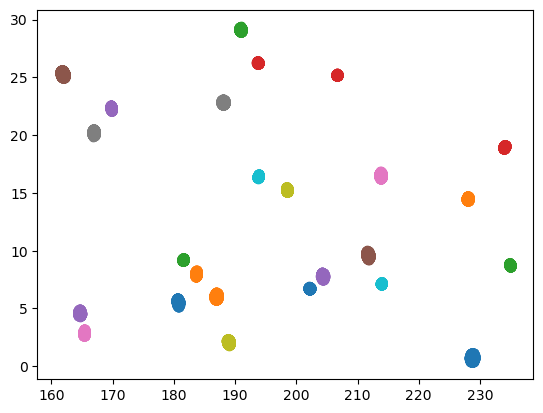

In [6]:
for i in range(len(subcatalogs)):
    plt.scatter(subcatalog_list[i]['ra_gal'], subcatalog_list[i]['dec_gal'])

In [9]:
for hid in unique_halo_ids:
    subcat = catalog[catalog['halo_id'] == hid]

    hdu = fits.BinTableHDU(data=subcat, header=data_header)
    hdu_primary = fits.PrimaryHDU()
    hdul_new = fits.HDUList([hdu_primary, hdu])
    out_file = f'cluster_init_data/{hid}_data.fits'
    hdul_new.writeto(out_file, overwrite=True)
    print(f"Saved {out_file} with {len(subcat)} rows.")

Saved cluster_init_data/3540350196678_data.fits with 5409 rows.
Saved cluster_init_data/3542370665932_data.fits with 2964 rows.
Saved cluster_init_data/3544360043075_data.fits with 2796 rows.
Saved cluster_init_data/3545380349863_data.fits with 3051 rows.
Saved cluster_init_data/3739350897596_data.fits with 3175 rows.
Saved cluster_init_data/3740360074867_data.fits with 6135 rows.
Saved cluster_init_data/3740360529492_data.fits with 3146 rows.
Saved cluster_init_data/3838370682076_data.fits with 2701 rows.
Saved cluster_init_data/3840360729382_data.fits with 4616 rows.
Saved cluster_init_data/3845360361913_data.fits with 1343 rows.
Saved cluster_init_data/3938350271698_data.fits with 3140 rows.
Saved cluster_init_data/3939350664369_data.fits with 4248 rows.
Saved cluster_init_data/3939380821520_data.fits with 4319 rows.
Saved cluster_init_data/3943390113633_data.fits with 1449 rows.
Saved cluster_init_data/4036350332263_data.fits with 3116 rows.
Saved cluster_init_data/4036370818677_da